# 01 · Pillar 1 — the data layer
Ingest → standardise (OUF 2.5) → partial-access reads → weights. Real eBOSS DR16Q QSO if the data is present, else a synthetic stand-in. **No cosmology** lives in Pillar 1.

In [1]:
%matplotlib inline
import os, sys, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
HAVE_EBOSS = EBOSS.exists()
print('real eBOSS data available:', HAVE_EBOSS)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real eBOSS data available: True


In [2]:
def eboss_or_synth_view(tmp, n_cap=40000):
    from fixtures.measure_ouf import synthetic_point_view
    from oneuniverse.data.converter import write_ouf_dataset
    from oneuniverse.data.dataset_view import DatasetView
    from oneuniverse.data.format_spec import DataGeometry
    from oneuniverse.data.manifest import LoaderSpec
    if not HAVE_EBOSS:
        return synthetic_point_view(tmp, n=n_cap, seed=1, name='synth'), False
    os.environ['ONEUNIVERSE_DATA_ROOT']=DATA_ROOT
    from oneuniverse.data import load_catalog
    df = load_catalog('eboss_qso', validate=False)
    df = df[(df['z']>=0.8)&(df['z']<=2.2)].dropna(subset=['ra','dec','z'])
    if len(df)>n_cap: df=df.sample(n_cap, random_state=0)
    df=df.reset_index(drop=True); n=len(df)
    ra=df['ra'].to_numpy(float); dec=df['dec'].to_numpy(float)
    out=pd.DataFrame({'ra':ra,'dec':dec,'z':df['z'].to_numpy(float),
        'z_type':np.full(n,'spec'),'z_err':np.full(n,1e-4),
        'galaxy_id':np.arange(n,dtype=np.int64),'survey_id':np.zeros(n,dtype=np.int64),
        'weight_comp':np.ones(n),'nbar':np.full(n,1e-3),
        '_original_row_index':np.arange(n,dtype='i8'),
        '_healpix32':hp.ang2pix(32,ra,dec,nest=True,lonlat=True).astype('i4')})
    od=tmp/'eboss'/'oneuniverse'
    write_ouf_dataset(df=out,out_dir=od,survey_name='eboss',survey_type='spectroscopic',
        geometry=DataGeometry.POINT,loader=LoaderSpec(name='eboss',version='0'))
    return DatasetView.from_path(od.parent), True
view, real = eboss_or_synth_view(TMP)
print('source:', 'REAL eBOSS DR16Q' if real else 'synthetic',
      '| geometry:', view.geometry.value, '| rows:', view.n_rows)
print('CORE columns:', [c for c in view.columns if not c.startswith('_')][:9])

source: REAL eBOSS DR16Q | geometry: point | rows: 40000
CORE columns: ['ra', 'dec', 'z', 'z_type', 'z_err', 'galaxy_id', 'survey_id', 'weight_comp', 'nbar']


## Partial-access reads — only the partitions you need
`DatasetView` prunes HEALPix partitions by sky/redshift selector.

full read: 40,000 rows | cone(10 deg) read: 1,343 rows


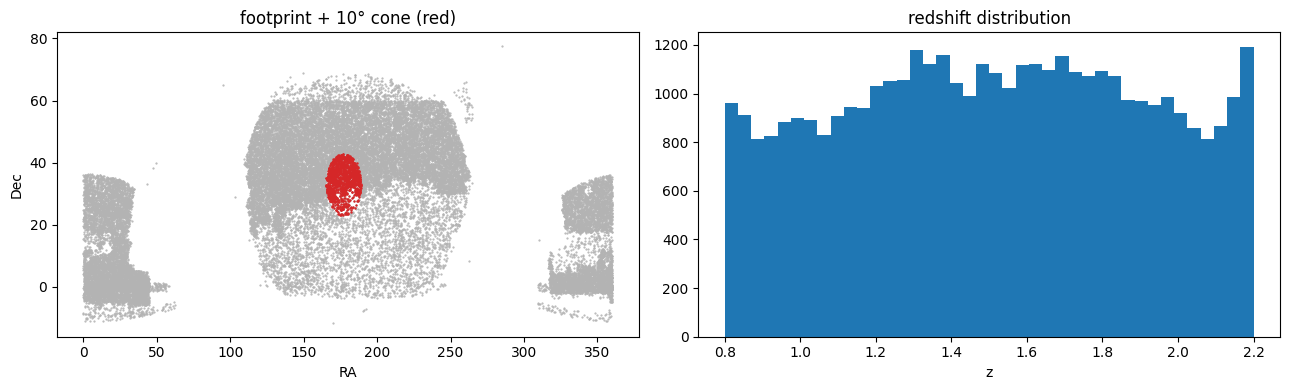

In [3]:
from oneuniverse.data.selection import Cone
full = view.read(columns=['ra','dec','z'])
ctr_ra, ctr_dec = float(full['ra'].median()), float(full['dec'].median())
sub = view.read(columns=['ra','dec','z'], cone=Cone(ra=ctr_ra, dec=ctr_dec, radius=10))
print(f'full read: {len(full):,} rows | cone(10 deg) read: {len(sub):,} rows')
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].scatter(full['ra'],full['dec'],s=.3,c='.7'); ax[0].scatter(sub['ra'],sub['dec'],s=.5,c='C3')
ax[0].set_title('footprint + 10° cone (red)'); ax[0].set_xlabel('RA'); ax[0].set_ylabel('Dec')
ax[1].hist(full['z'],bins=40); ax[1].set_title('redshift distribution'); ax[1].set_xlabel('z')
plt.tight_layout(); plt.show()

## Weights — composable primitives (cosmology-free)
`oneuniverse.combine` weight families: FKP, completeness, systematics, shear, PIP bitwise. Here FKP × completeness.

FKP weight (constant n̄): 0.0909 | total = FKP×comp


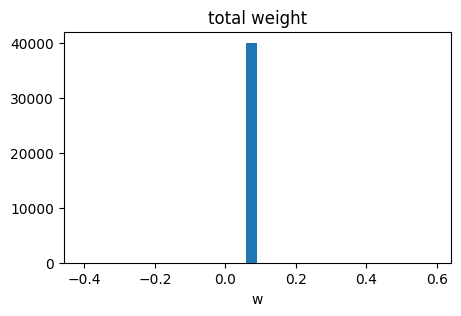

In [4]:
from oneuniverse.combine.weights import FKPWeight, ColumnWeight
df = view.read()
if 'nbar' not in df: df['nbar']=1e-3
if 'weight_comp' not in df: df['weight_comp']=1.0
fkp = FKPWeight(nbar=lambda z: np.full_like(z,1e-3), P0=1e4)(df)
comp = ColumnWeight('weight_comp')(df)
print('FKP weight (constant n̄):', round(float(fkp[0]),4), '| total = FKP×comp')
plt.figure(figsize=(5,3)); plt.hist(fkp*comp, bins=30)
plt.title('total weight'); plt.xlabel('w'); plt.show()

## Photo-z PDF kernels (synthetic)
OUF stores per-object p(z) (`qp`-style); `DatasetView.load_pdf()` reconstructs it. Photometric probes carry this kernel into Pillar 2.

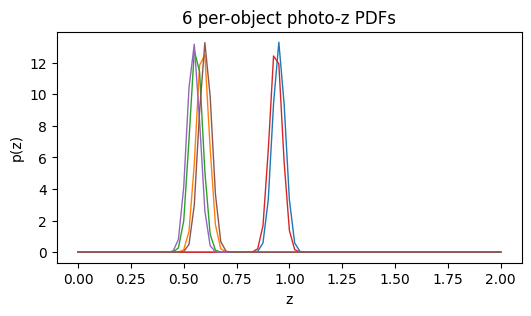

kernel mean shape: (1500,)


In [5]:
from fixtures.measure_ouf import synthetic_shear_view
pview = synthetic_shear_view(TMP, n=1500, seed=2, with_pdf=True, name='pdf')
pz = pview.load_pdf()
plt.figure(figsize=(6,3))
for i in range(6): plt.plot(pz.grid, pz.values[i], lw=1)
plt.title('6 per-object photo-z PDFs'); plt.xlabel('z'); plt.ylabel('p(z)'); plt.show()
print('kernel mean shape:', pz.mean().shape)

**Recap.** Pillar 1 = one standardised, partial-access, weighted, cross-matchable database — verbatim survey data + observational metadata only. Cosmology enters downstream.